In [ ]:
!pip install pandas numpy scikit-learn torch torchvision torchaudio

^C


  Using cached pandas-2.3.3-cp39-cp39-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.0.2-cp39-cp39-win_amd64.whl.metadata (59 kB)
  Using cached scikit_learn-1.6.1-cp39-cp39-win_amd64.whl.metadata (15 kB)
  Using cached torch-2.8.0-cp39-cp39-win_amd64.whl.metadata (30 kB)
  Using cached torchvision-0.23.0-cp39-cp39-win_amd64.whl.metadata (6.1 kB)
  Using cached torchaudio-2.8.0-cp39-cp39-win_amd64.whl.metadata (7.2 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached scipy-1.13.1-cp39-cp39-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached filelock-3.19.1-py3-none-any.whl.metadata (2.1 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.2.1-py3-none-any.whl.metadata (5.2 kB)
  Using cached jinja2-3.1.6-py3-none-any.wh

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

train_df = pd.read_csv('train_format1.csv')
test_df = pd.read_csv('test_format1.csv')

print("Distribución del dataset:")
print(train_df['label'].value_counts())
print(f"\nPorcentaje clase 0: {train_df['label'].value_counts()[0] / len(train_df):.4f}")
print(f"Porcentaje clase 1: {train_df['label'].value_counts()[1] / len(train_df):.4f}")

Distribución del dataset:
label
0    244733
1     16131
Name: count, dtype: int64

Porcentaje clase 0: 0.9382
Porcentaje clase 1: 0.0618


In [ ]:
from sklearn.preprocessing import LabelEncoder

train_df = pd.read_csv('train_format1.csv')
test_df = pd.read_csv('test_format1.csv')
user_info_df = pd.read_csv('user_info_format1.csv')


user_log_df = pd.read_csv('user_log_format1.csv', nrows=10000000)  


user_log_df.rename(columns={'seller_id': 'merchant_id'}, inplace=True)

relevant_users = set(train_df['user_id'].unique()) | set(test_df['user_id'].unique())
user_log_df = user_log_df[user_log_df['user_id'].isin(relevant_users)]
print(f"User log filtrado a usuarios relevantes: {len(user_log_df)} filas")

behavior_features = user_log_df.groupby(['user_id', 'merchant_id', 'action_type']).size().unstack(fill_value=0)
behavior_features.rename(columns={0: 'clicks', 1: 'add_to_cart', 2: 'purchase', 3: 'add_to_favorites'}, inplace=True)
behavior_features.reset_index(inplace=True)

train_df = train_df.merge(user_info_df, on='user_id', how='left')
train_df = train_df.merge(behavior_features, on=['user_id', 'merchant_id'], how='left')
train_df.fillna(0, inplace=True)

test_df = test_df.merge(user_info_df, on='user_id', how='left')
test_df = test_df.merge(behavior_features, on=['user_id', 'merchant_id'], how='left')
test_df.fillna(0, inplace=True)

train_df['conversion_rate'] = train_df['purchase'] / (train_df['clicks'] + 1)
test_df['conversion_rate'] = test_df['purchase'] / (test_df['clicks'] + 1)

train_df['total_interactions'] = train_df['clicks'] + train_df['add_to_cart'] + train_df['purchase'] + train_df['add_to_favorites']
test_df['total_interactions'] = test_df['clicks'] + test_df['add_to_cart'] + test_df['purchase'] + test_df['add_to_favorites']

print(f"\nCobertura de usuarios con interacciones:")
print(f"Train: {(train_df['total_interactions'] > 0).sum()} / {len(train_df)} ({(train_df['total_interactions'] > 0).sum()/len(train_df)*100:.1f}%)")

le_user = LabelEncoder()
le_merchant = LabelEncoder()

train_df['user_encoded'] = le_user.fit_transform(train_df['user_id'])
train_df['merchant_encoded'] = le_merchant.fit_transform(train_df['merchant_id'])

test_df['user_encoded'] = test_df['user_id'].map(dict(zip(le_user.classes_, le_user.transform(le_user.classes_)))).fillna(-1).astype(int)
test_df['merchant_encoded'] = test_df['merchant_id'].map(dict(zip(le_merchant.classes_, le_merchant.transform(le_merchant.classes_)))).fillna(-1).astype(int)

feature_cols = ['user_encoded', 'merchant_encoded', 'age_range', 'gender', 
                'clicks', 'add_to_cart', 'purchase', 'add_to_favorites', 
                'conversion_rate', 'total_interactions']

X = train_df[feature_cols]
y = train_df['label']
X_test_final = test_df[feature_cols]

print(f"\nFeatures creadas: {X.shape}")
print("\nEstadísticas de comportamiento:")
print(train_df[['clicks', 'add_to_cart', 'purchase', 'add_to_favorites', 'total_interactions']].describe())

User log filtrado a usuarios relevantes: 9999008 filas

Cobertura de usuarios con interacciones:
Train: 46320 / 260864 (17.8%)

Features creadas: (260864, 10)

Estadísticas de comportamiento:
              clicks    add_to_cart       purchase  add_to_favorites  \
count  260864.000000  260864.000000  260864.000000     260864.000000   
mean        1.644589       0.003826       0.241632          0.070063   
std         8.193408       0.083440       0.642507          0.626161   
min         0.000000       0.000000       0.000000          0.000000   
25%         0.000000       0.000000       0.000000          0.000000   
50%         0.000000       0.000000       0.000000          0.000000   
75%         0.000000       0.000000       0.000000          0.000000   
max       560.000000      10.000000      10.000000         59.000000   

       total_interactions  
count       260864.000000  
mean             1.960109  
std              8.855522  
min              0.000000  
25%              0.

In [13]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

In [33]:
custom_weights = {0: 1.0, 1: class_weights[1] * 2.0}

In [14]:
lr_model = LogisticRegression(
    max_iter=2000,
    C=0.1,
    class_weight='balanced',
    random_state=42,
    solver='saga'
)
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_val_scaled)
lr_pred_proba = lr_model.predict_proba(X_val_scaled)[:, 1]

print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_val, lr_pred):.4f}")
print(f"Precision: {precision_score(y_val, lr_pred):.4f}")
print(f"Recall: {recall_score(y_val, lr_pred):.4f}")
print(f"F1-Score: {f1_score(y_val, lr_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, lr_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, lr_pred))

Logistic Regression Results:
Accuracy: 0.5563
Precision: 0.0683
Recall: 0.4882
F1-Score: 0.1198
ROC-AUC: 0.5303

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.56      0.70     48947
           1       0.07      0.49      0.12      3226

    accuracy                           0.56     52173
   macro avg       0.51      0.52      0.41     52173
weighted avg       0.89      0.56      0.67     52173



In [38]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight=custom_weights,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_val_scaled)
rf_pred_proba = rf_model.predict_proba(X_val_scaled)[:, 1]

print("Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_val, rf_pred):.4f}")
print(f"Precision: {precision_score(y_val, rf_pred):.4f}")
print(f"Recall: {recall_score(y_val, rf_pred):.4f}")
print(f"F1-Score: {f1_score(y_val, rf_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, rf_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, rf_pred))

Random Forest Results:
Accuracy: 0.6144
Precision: 0.0718
Recall: 0.4392
F1-Score: 0.1235
ROC-AUC: 0.5432

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.63      0.75     48947
           1       0.07      0.44      0.12      3226

    accuracy                           0.61     52173
   macro avg       0.51      0.53      0.44     52173
weighted avg       0.89      0.61      0.71     52173



In [19]:
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X.values)
        self.y = torch.LongTensor(y.values)
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class GNNModel(nn.Module):
    def __init__(self, input_dim=10, hidden_dim=256, output_dim=2):
        super(GNNModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.bn3 = nn.BatchNorm1d(hidden_dim // 2)
        self.fc4 = nn.Linear(hidden_dim // 2, output_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.4)
        
    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.relu(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        x = self.fc4(x)
        return x

In [20]:
train_dataset = TabularDataset(X_train_scaled, y_train)
val_dataset = TabularDataset(X_val_scaled, y_val)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gnn_model = GNNModel(input_dim=10).to(device)

criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, class_weights[1]/class_weights[0]], dtype=torch.float32).to(device))
optimizer = optim.Adam(gnn_model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

In [21]:
num_epochs = 50

for epoch in range(num_epochs):
    gnn_model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.float().to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = gnn_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    scheduler.step(avg_train_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_train_loss:.4f}")

Epoch 5/50, Loss: 0.6894
Epoch 10/50, Loss: 0.6888
Epoch 15/50, Loss: 0.6887
Epoch 20/50, Loss: 0.6886
Epoch 25/50, Loss: 0.6875
Epoch 30/50, Loss: 0.6874
Epoch 35/50, Loss: 0.6872
Epoch 40/50, Loss: 0.6867
Epoch 45/50, Loss: 0.6867
Epoch 50/50, Loss: 0.6867


In [22]:
gnn_model.eval()
gnn_predictions = []
gnn_predictions_proba = []
with torch.no_grad():
    for X_batch, _ in val_loader:
        X_batch = X_batch.to(device)
        outputs = gnn_model(X_batch)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        gnn_predictions.extend(predicted.cpu().numpy())
        gnn_predictions_proba.extend(probs[:, 1].cpu().numpy())

print("GNN Results:")
print(f"Accuracy: {accuracy_score(y_val, gnn_predictions):.4f}")
print(f"Precision: {precision_score(y_val, gnn_predictions):.4f}")
print(f"Recall: {recall_score(y_val, gnn_predictions):.4f}")
print(f"F1-Score: {f1_score(y_val, gnn_predictions):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, gnn_predictions_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, gnn_predictions))

GNN Results:
Accuracy: 0.6760
Precision: 0.0739
Recall: 0.3676
F1-Score: 0.1230
ROC-AUC: 0.5474

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.70      0.80     48947
           1       0.07      0.37      0.12      3226

    accuracy                           0.68     52173
   macro avg       0.51      0.53      0.46     52173
weighted avg       0.89      0.68      0.76     52173



In [23]:
class DeepFM(nn.Module):
    def __init__(self, input_dim=10, embed_dim=16, hidden_dims=[256, 128, 64]):
        super(DeepFM, self).__init__()
        
        self.input_dim = input_dim
        self.embed_dim = embed_dim
        
        self.linear = nn.Linear(input_dim, 1)
        self.embeddings = nn.Parameter(torch.randn(input_dim, embed_dim) * 0.01)
        
        deep_layers = []
        in_dim = input_dim * embed_dim
        for hidden_dim in hidden_dims:
            deep_layers.append(nn.Linear(in_dim, hidden_dim))
            deep_layers.append(nn.BatchNorm1d(hidden_dim))
            deep_layers.append(nn.ReLU())
            deep_layers.append(nn.Dropout(0.4))
            in_dim = hidden_dim
        deep_layers.append(nn.Linear(in_dim, 1))
        self.deep = nn.Sequential(*deep_layers)
        
    def forward(self, x):
        linear_part = self.linear(x)
        
        embed = x.unsqueeze(2) * self.embeddings.unsqueeze(0)
        
        sum_squared = torch.sum(embed, dim=1) ** 2
        squared_sum = torch.sum(embed ** 2, dim=1)
        fm_part = 0.5 * torch.sum(sum_squared - squared_sum, dim=1, keepdim=True)
        
        deep_input = embed.reshape(x.size(0), -1)
        deep_part = self.deep(deep_input)
        
        output = linear_part + fm_part + deep_part
        return output

In [24]:
pos_weight = torch.tensor([class_weights[1] / class_weights[0]]).to(device)

deepfm_model = DeepFM(input_dim=10).to(device)
criterion_deepfm = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_deepfm = optim.Adam(deepfm_model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler_deepfm = optim.lr_scheduler.ReduceLROnPlateau(optimizer_deepfm, mode='min', patience=3)

In [25]:
num_epochs = 20
for epoch in range(num_epochs):
    deepfm_model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.float().to(device)
        
        optimizer_deepfm.zero_grad()
        outputs = deepfm_model(X_batch).squeeze()
        loss = criterion_deepfm(outputs, y_batch)
        loss.backward()
        optimizer_deepfm.step()
        
        train_loss += loss.item()
    
    avg_loss = train_loss / len(train_loader)
    scheduler_deepfm.step(avg_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 5/20, Loss: 1.2942
Epoch 10/20, Loss: 1.2934
Epoch 15/20, Loss: 1.2935
Epoch 20/20, Loss: 1.2931


In [26]:
deepfm_model.eval()
deepfm_predictions = []
deepfm_predictions_proba = []
with torch.no_grad():
    for X_batch, _ in val_loader:
        X_batch = X_batch.to(device)
        outputs = deepfm_model(X_batch).squeeze()
        probs = torch.sigmoid(outputs)
        predicted = (probs > 0.5).long()
        deepfm_predictions.extend(predicted.cpu().numpy())
        deepfm_predictions_proba.extend(probs.cpu().numpy())

print("DeepFM Results:")
print(f"Accuracy: {accuracy_score(y_val, deepfm_predictions):.4f}")
print(f"Precision: {precision_score(y_val, deepfm_predictions):.4f}")
print(f"Recall: {recall_score(y_val, deepfm_predictions):.4f}")
print(f"F1-Score: {f1_score(y_val, deepfm_predictions):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, deepfm_predictions_proba):.4f}")

DeepFM Results:
Accuracy: 0.3940
Precision: 0.0658
Recall: 0.6668
F1-Score: 0.1198
ROC-AUC: 0.5374


In [27]:
print("Distribución de clases en validación:")
print(y_val.value_counts())
print(f"\nPorcentaje de clase mayoritaria: {y_val.value_counts().max() / len(y_val):.4f}")

print("\nPredicciones Logistic Regression:")
print(pd.Series(lr_pred).value_counts())
print(f"\nPredicciones Random Forest:")
print(pd.Series(rf_pred).value_counts())
print(f"\nPredicciones GNN:")
print(pd.Series(gnn_predictions).value_counts())
print(f"\nPredicciones DeepFM:")
print(pd.Series(deepfm_predictions).value_counts())

print("\nConfusion Matrix - Logistic Regression:")
print(confusion_matrix(y_val, lr_pred))
print("\nConfusion Matrix - Random Forest:")
print(confusion_matrix(y_val, rf_pred))
print("\nConfusion Matrix - GNN:")
print(confusion_matrix(y_val, gnn_predictions))
print("\nConfusion Matrix - DeepFM:")
print(confusion_matrix(y_val, deepfm_predictions))

Distribución de clases en validación:
label
0    48947
1     3226
Name: count, dtype: int64

Porcentaje de clase mayoritaria: 0.9382

Predicciones Logistic Regression:
0    29099
1    23074
Name: count, dtype: int64

Predicciones Random Forest:
0    38935
1    13238
Name: count, dtype: int64

Predicciones GNN:
0    36121
1    16052
Name: count, dtype: int64

Predicciones DeepFM:
1    32692
0    19481
Name: count, dtype: int64

Confusion Matrix - Logistic Regression:
[[27448 21499]
 [ 1651  1575]]

Confusion Matrix - Random Forest:
[[36707 12240]
 [ 2228   998]]

Confusion Matrix - GNN:
[[34081 14866]
 [ 2040  1186]]

Confusion Matrix - DeepFM:
[[18406 30541]
 [ 1075  2151]]


In [28]:
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'GNN', 'DeepFM'],
    'Accuracy': [
        accuracy_score(y_val, lr_pred),
        accuracy_score(y_val, rf_pred),
        accuracy_score(y_val, gnn_predictions),
        accuracy_score(y_val, deepfm_predictions)
    ],
    'Precision': [
        precision_score(y_val, lr_pred, zero_division=0),
        precision_score(y_val, rf_pred, zero_division=0),
        precision_score(y_val, gnn_predictions, zero_division=0),
        precision_score(y_val, deepfm_predictions, zero_division=0)
    ],
    'Recall': [
        recall_score(y_val, lr_pred, zero_division=0),
        recall_score(y_val, rf_pred, zero_division=0),
        recall_score(y_val, gnn_predictions, zero_division=0),
        recall_score(y_val, deepfm_predictions, zero_division=0)
    ],
    'F1-Score': [
        f1_score(y_val, lr_pred, zero_division=0),
        f1_score(y_val, rf_pred, zero_division=0),
        f1_score(y_val, gnn_predictions, zero_division=0),
        f1_score(y_val, deepfm_predictions, zero_division=0)
    ],
    'ROC-AUC': [
        roc_auc_score(y_val, lr_pred_proba),
        roc_auc_score(y_val, rf_pred_proba),
        roc_auc_score(y_val, gnn_predictions_proba),
        roc_auc_score(y_val, deepfm_predictions_proba)
    ]
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('ROC-AUC', ascending=False)
print("\nModel Comparison (Complete):")
print(results_df)

best_model_name = results_df.iloc[0]['Model']
print(f"\nBest Model: {best_model_name}")


Model Comparison (Complete):
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
2                  GNN  0.675963   0.073885  0.367638  0.123042  0.547434
1        Random Forest  0.722692   0.075389  0.309361  0.121234  0.543399
3               DeepFM  0.394016   0.065796  0.666770  0.119773  0.537384
0  Logistic Regression  0.556284   0.068259  0.488221  0.119772  0.530329

Best Model: GNN


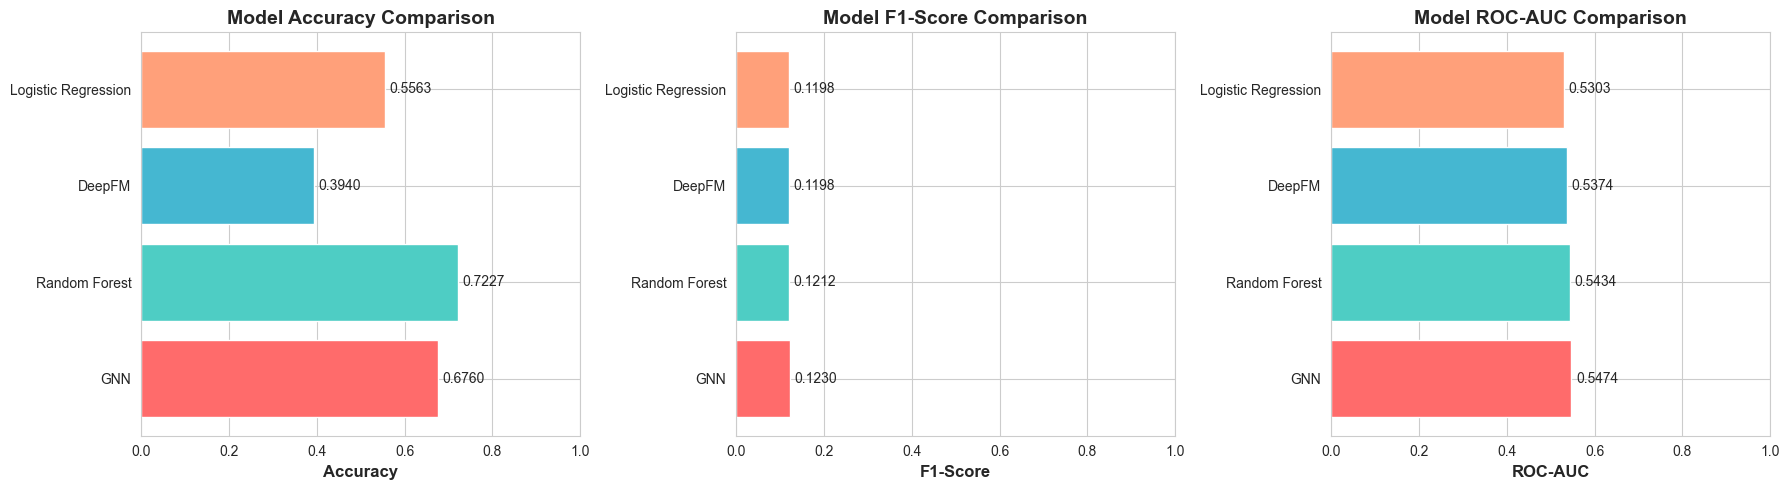

In [29]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = results_df['Model'].tolist()
accuracies = results_df['Accuracy'].tolist()
f1_scores = results_df['F1-Score'].tolist()
roc_aucs = results_df['ROC-AUC'].tolist()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

axes[0].barh(models, accuracies, color=colors)
axes[0].set_xlabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlim(0, 1)
for i, v in enumerate(accuracies):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

axes[1].barh(models, f1_scores, color=colors)
axes[1].set_xlabel('F1-Score', fontsize=12, fontweight='bold')
axes[1].set_title('Model F1-Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlim(0, 1)
for i, v in enumerate(f1_scores):
    axes[1].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

axes[2].barh(models, roc_aucs, color=colors)
axes[2].set_xlabel('ROC-AUC', fontsize=12, fontweight='bold')
axes[2].set_title('Model ROC-AUC Comparison', fontsize=14, fontweight='bold')
axes[2].set_xlim(0, 1)
for i, v in enumerate(roc_aucs):
    axes[2].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

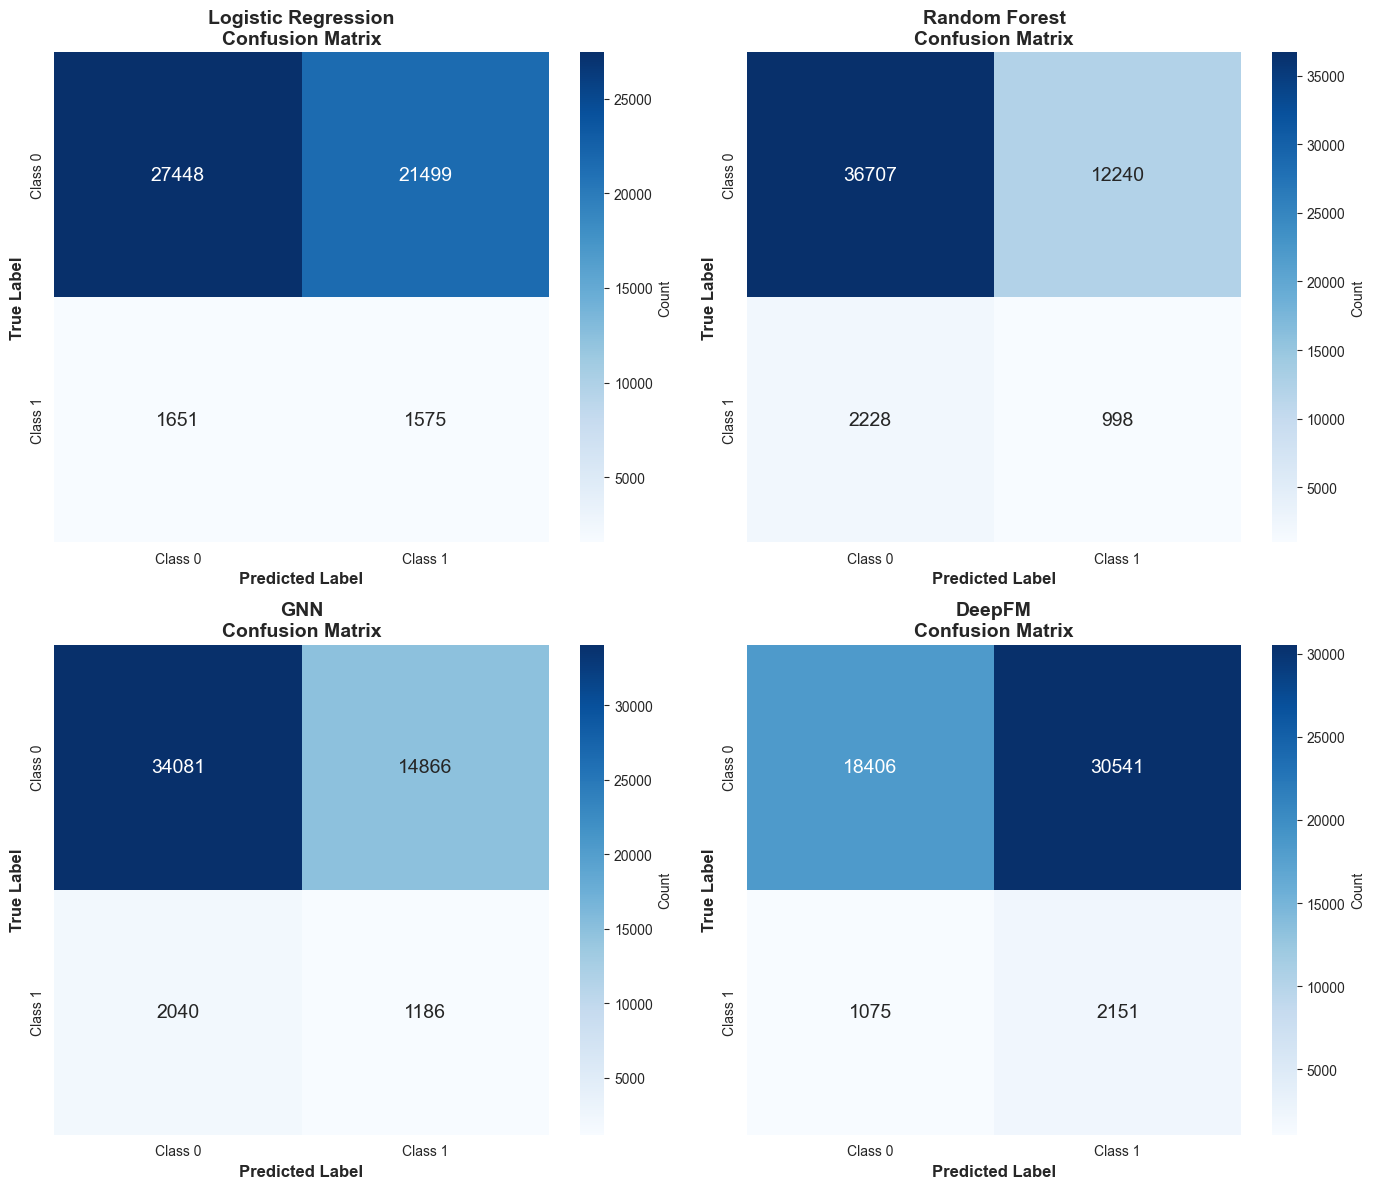

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

confusion_matrices = [
    ('Logistic Regression', confusion_matrix(y_val, lr_pred)),
    ('Random Forest', confusion_matrix(y_val, rf_pred)),
    ('GNN', confusion_matrix(y_val, gnn_predictions)),
    ('DeepFM', confusion_matrix(y_val, deepfm_predictions))
]

for idx, (model_name, cm) in enumerate(confusion_matrices):
    row = idx // 2
    col = idx % 2
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, col], 
                cbar_kws={'label': 'Count'}, annot_kws={'size': 14})
    axes[row, col].set_title(f'{model_name}\nConfusion Matrix', fontsize=14, fontweight='bold')
    axes[row, col].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    axes[row, col].set_ylabel('True Label', fontsize=12, fontweight='bold')
    axes[row, col].set_xticklabels(['Class 0', 'Class 1'])
    axes[row, col].set_yticklabels(['Class 0', 'Class 1'])

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

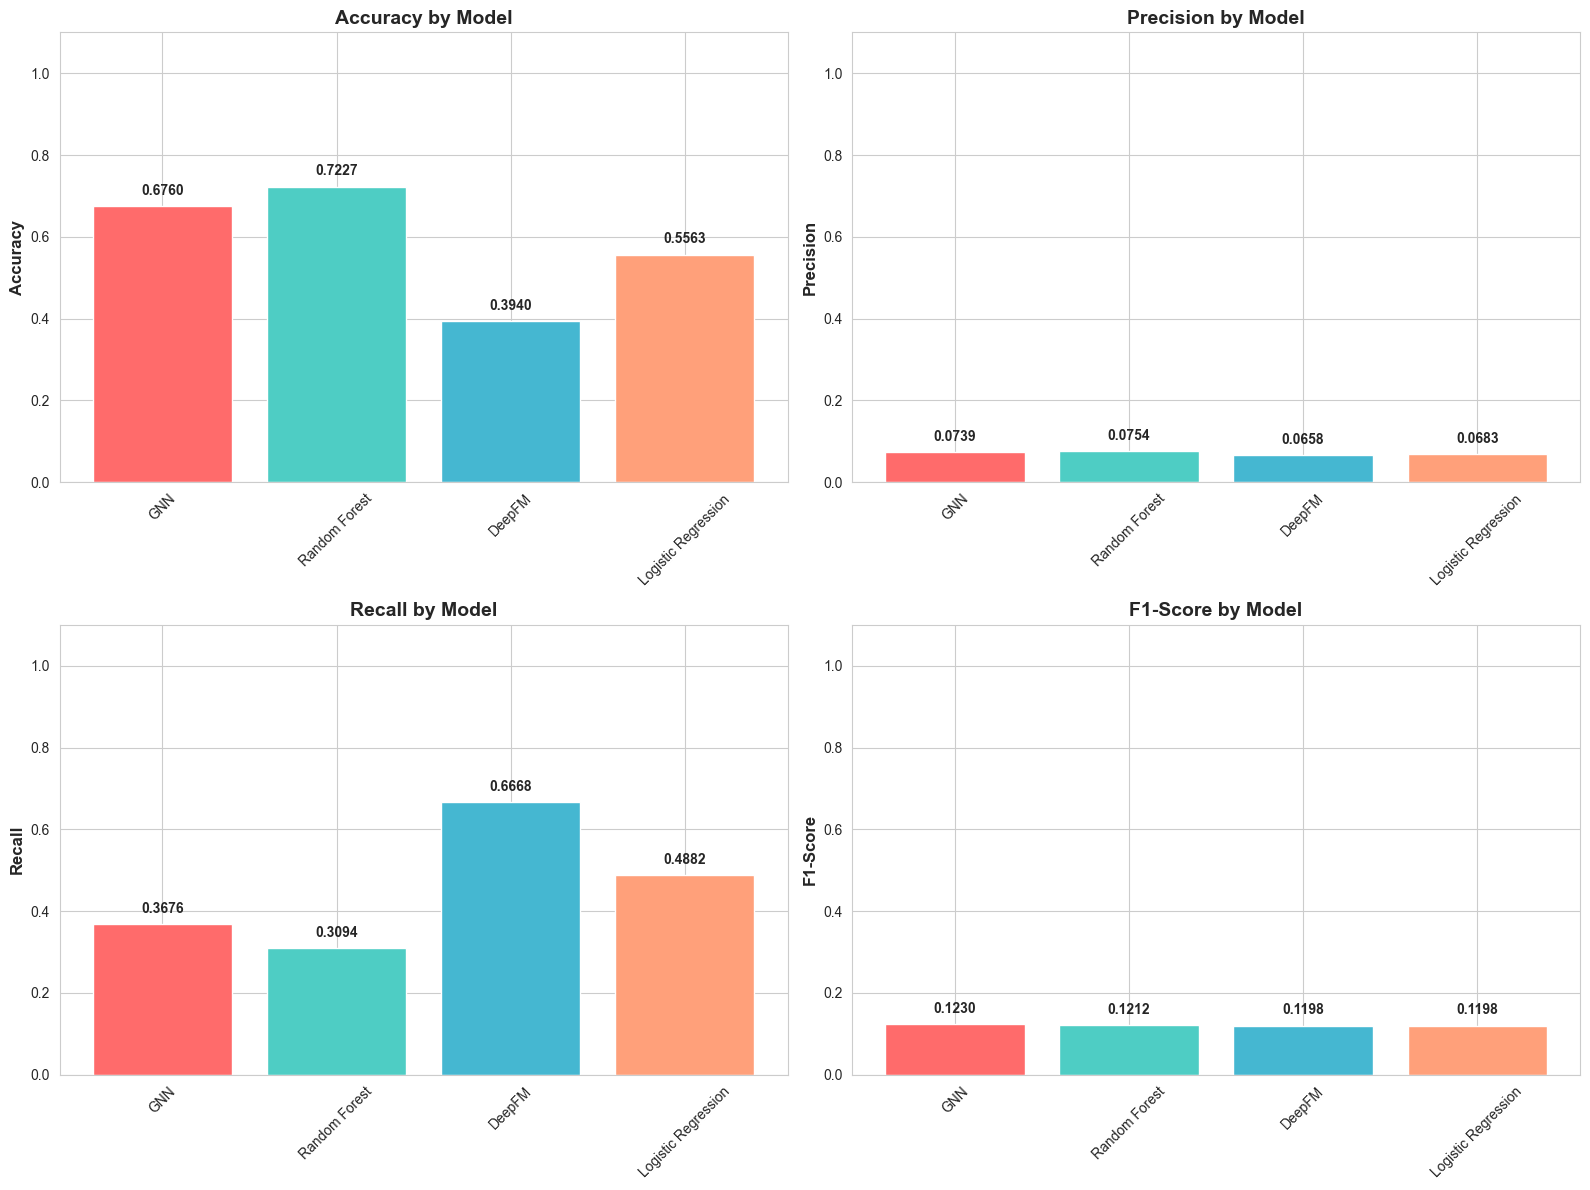

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for idx, metric in enumerate(metrics):
    row = idx // 2
    col = idx % 2
    
    values = results_df[metric].tolist()
    models = results_df['Model'].tolist()
    
    bars = axes[row, col].bar(models, values, color=colors)
    axes[row, col].set_ylabel(metric, fontsize=12, fontweight='bold')
    axes[row, col].set_title(f'{metric} by Model', fontsize=14, fontweight='bold')
    axes[row, col].set_ylim(0, 1.1)
    axes[row, col].tick_params(axis='x', rotation=45)
    
    for bar, v in zip(bars, values):
        height = bar.get_height()
        axes[row, col].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                           f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'models_data' is not defined

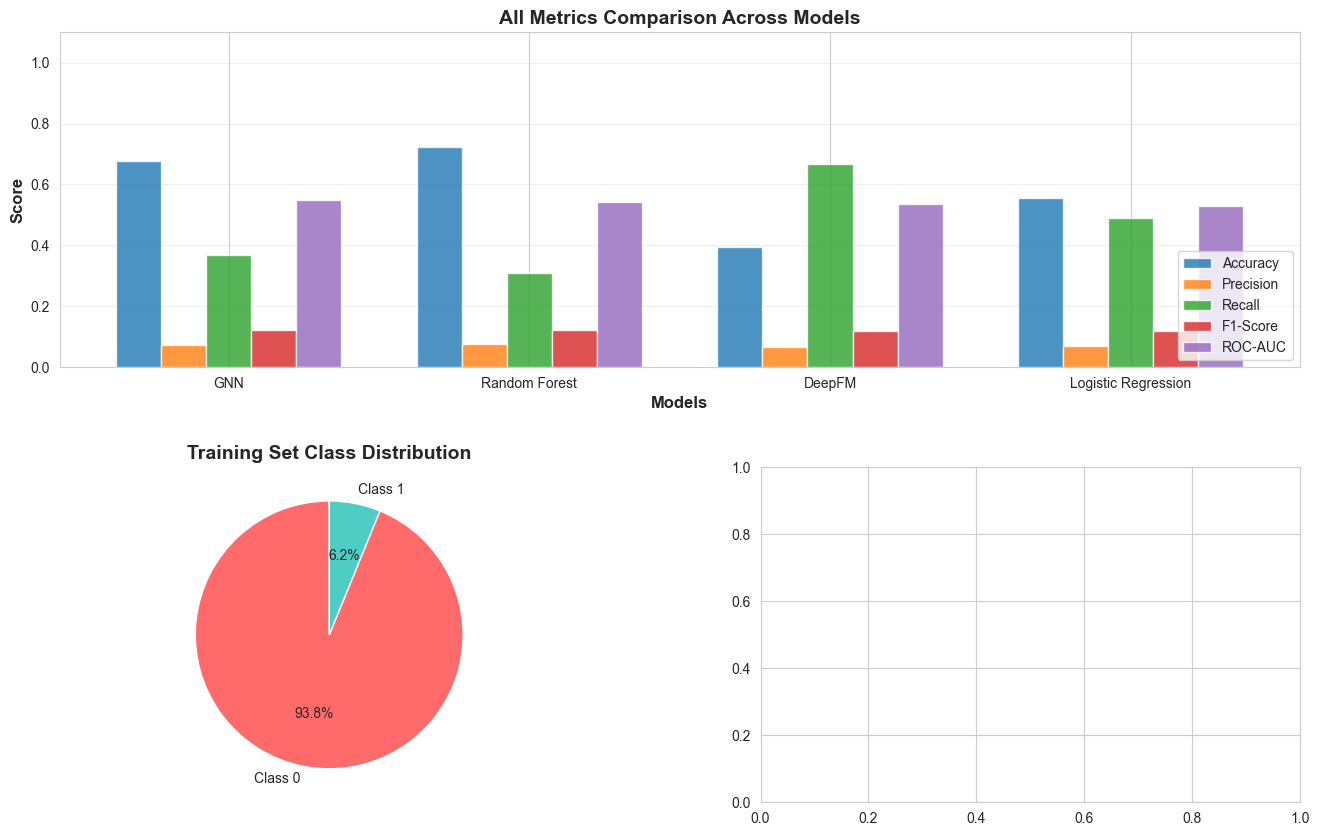

In [32]:
fig = plt.figure(figsize=(16, 10))

gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

models = results_df['Model'].tolist()
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(models))
width = 0.15

for i, metric in enumerate(metrics_to_plot):
    values = results_df[metric].tolist()
    offset = width * (i - 2)
    ax1.bar(x + offset, values, width, label=metric, alpha=0.8)

ax1.set_xlabel('Models', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('All Metrics Comparison Across Models', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=0)
ax1.legend(loc='lower right', fontsize=10)
ax1.set_ylim(0, 1.1)
ax1.grid(axis='y', alpha=0.3)

class_dist = y_train.value_counts()
ax2.pie(class_dist.values, labels=[f'Class {i}' for i in class_dist.index], 
        autopct='%1.1f%%', startangle=90, colors=['#FF6B6B', '#4ECDC4'])
ax2.set_title('Training Set Class Distribution', fontsize=14, fontweight='bold')

model_colors = {'Logistic Regression': '#FF6B6B', 'Random Forest': '#4ECDC4', 
                'GNN': '#45B7D1', 'DeepFM': '#FFA07A'}
for model_name, pred_proba in models_data:
    fpr, tpr, _ = roc_curve(y_val, pred_proba)
    roc_auc = auc(fpr, tpr)
    ax3.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC={roc_auc:.3f})', 
             color=model_colors[model_name])

ax3.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
ax3.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax3.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax3.set_title('ROC Curves - All Models', fontsize=14, fontweight='bold')
ax3.legend(loc='lower right', fontsize=9)
ax3.grid(alpha=0.3)

plt.savefig('comprehensive_analysis.png', dpi=300, bbox_inches='tight')
plt.show()